<a href="https://colab.research.google.com/github/NazalRazi/Myfiles/blob/main/swiftlink_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import ipywidgets as widgets
from IPython.display import display, HTML

# 1. Dataset definition
MEDICAL = [
    "Chest pain and difficulty breathing", "Unconscious person on the floor",
    "Heavy bleeding from a wound", "Heart attack symptoms",
    "Someone is having a seizure", "Person is not breathing",
    "Severe head injury after fall", "Snake bite on the leg",
    "Drug overdose emergency", "Child swallowed poison",
    "High fever and convulsions", "Choking on food",
    "Stroke symptoms face drooping", "Severe burn on the arm",
    "Asthma attack without inhaler", "Person collapsed suddenly",
    "Deep cut on the hand", "Severe stomach pain",
    "I fell from the stairs and cant get up", "My back is broken after a fall",
    "Fell down and cant move my legs", "Spinal injury after falling",
    "Can't feel my legs after the fall", "Broken arm after fall",
    "I fell and I am in severe pain", "Ambulance needed immediately",
    "Patient losing consciousness", "Bleeding wont stop",
    "Need oxygen immediately", "Breathing difficulty increasing",
    "Cardiac arrest need CPR", "Electric shock injury",
    "Heat stroke victim", "Fainted and not responding",
    "Pulse is very weak", "Toddler has high fever",
    "Elderly person having chest pain", "Unconscious after accident",
    "Baby stopped breathing", "Emergency surgery needed",
    "ശ്വാസം നിലക്കുന്നു", "പരിക്ക് ഗുരുതരമാണ്",
    "എനിക്ക് ശ്വാസം എടുക്കാൻ കഴിയുന്നില്ല", "എനിക്ക് പരിക്കേറ്റു",
]

FIRE = [
    "Smoke filling the building", "Gas leak in the kitchen",
    "Fire in the kitchen", "Building is on fire",
    "Electrical fire in the office", "Car is on fire on the road",
    "Smelling gas in the house", "Explosion followed by fire",
    "LPG cylinder on fire", "Fire trapped people inside",
    "Wildfire approaching the village", "Transformer exploded and burning",
    "Short circuit caused fire", "Multiple floors on fire",
    "Grease fire in restaurant", "Children trapped inside burning house",
    "Thick smoke everywhere", "The entire building is in flames",
    "Gas pipe burst and ignited", "Flame reaching the roof",
    "Burning smell in corridor", "Factory on fire workers inside",
    "Electrical panel exploded fire", "Fire emergency at residence",
    "Oil tank caught fire", "Smoke is everywhere send help",
    "Building engulfed in flames", "Flames visible from outside",
    "Gas cylinder exploded", "Fire outbreak in the market",
    "Fire blocking exit routes", "Roof on fire call fire brigade",
    "Fire in the lab chemicals burning", "Fire at fuel station",
    "Strong burning smell gas leak", "ഇവിടെ തീ പിടിത്തം",
    "തീ വ്യാപിക്കുന്നു", "Veedu theepidiche help cheyyu",
]

POLICE = [
    "Someone stole my wallet", "Theft happening in market",
    "Accident on the highway", "I am being harassed",
    "Domestic violence in progress", "Robbery at the store",
    "Kidnapping attempt witnessed", "Suspicious person following me",
    "Fight breaking out in street", "Murder suspect seen running",
    "Drunk driving causing chaos", "Drug dealing happening here",
    "Missing child in the area", "Stabbing incident in alley",
    "Mob attacking a person", "Hit and run accident",
    "Bomb threat in public place", "Person threatening with knife",
    "Road rage assault", "Breaking and entering happening",
    "Chain snatching on street", "Phone stolen at gunpoint",
    "Gang fight in neighbourhood", "Drunk and violent person",
    "Criminal running away", "Threat received need police",
    "Assault and battery happening", "Armed robbery at bank",
    "Someone attacked me", "Violent altercation in progress",
    "Stalking complaint", "Child abuse reported",
    "Hostage situation unfolding", "Sexual assault reported",
    "Unlawful detention of person", "Riot breaking out nearby",
    "Person with weapon spotted", "Child kidnapped near school",
    "Law enforcement needed urgently", "എന്നെ ആക്രമിച്ചു",
    "മോഷണം നടക്കുന്നു", "Ente phone kadhakki poya",
]

records = [(t,0) for t in MEDICAL] + [(t,1) for t in FIRE] + [(t,2) for t in POLICE]
df = pd.DataFrame(records, columns=["text","label"]).sample(frac=1, random_state=42).reset_index(drop=True)

LABEL_MAP = {0: "Medical", 1: "Fire", 2: "Police"}
RESPONSES = {
    0: "MEDICAL: Dispatching Ambulance. Check pulse and keep the patient warm.",
    1: "FIRE: Fire Brigade Alerted. Evacuate building and stay low to the ground.",
    2: "POLICE: Police Unit dispatched. Stay in a safe location and note descriptions."
}

In [ ]:
MODEL_NAME = "bert-base-multilingual-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["text"].tolist(), df["label"].tolist(), test_size=0.2, stratify=df["label"], random_state=42
)

def encode(texts):
    return tokenizer(texts, truncation=True, padding="max_length", max_length=64)

train_enc = encode(train_texts)
val_enc = encode(val_texts)

class EmergencyDataset(Dataset):
    def __init__(self, enc, labels):
        self.enc = enc
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        item = {k: torch.tensor(v[i]) for k,v in self.enc.items()}
        item["labels"] = torch.tensor(self.labels[i])
        return item

train_ds = EmergencyDataset(train_enc, train_labels)
val_ds = EmergencyDataset(val_enc, val_labels)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(device)

EPOCHS = 8
BATCH_SIZE = 16
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids, attention_mask=mask, labels=labels)
        outputs.loss.backward()
        optimizer.step()
        total_loss += outputs.loss.item()

    # Evaluation
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch in val_loader:
            out = model(batch["input_ids"].to(device), attention_mask=batch["attention_mask"].to(device))
            preds += torch.argmax(out.logits, dim=-1).cpu().tolist()
            trues += batch["labels"].tolist()

    print(f"Epoch {epoch} | Loss: {total_loss/len(train_loader):.4f} | Acc: {accuracy_score(trues, preds):.2%}")

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 | Loss: 1.0434 | Acc: 44.00%
Epoch 2 | Loss: 0.9468 | Acc: 88.00%
Epoch 3 | Loss: 0.7044 | Acc: 84.00%
Epoch 4 | Loss: 0.4056 | Acc: 92.00%
Epoch 5 | Loss: 0.2459 | Acc: 92.00%
Epoch 6 | Loss: 0.1034 | Acc: 92.00%
Epoch 7 | Loss: 0.0633 | Acc: 92.00%
Epoch 8 | Loss: 0.0666 | Acc: 80.00%


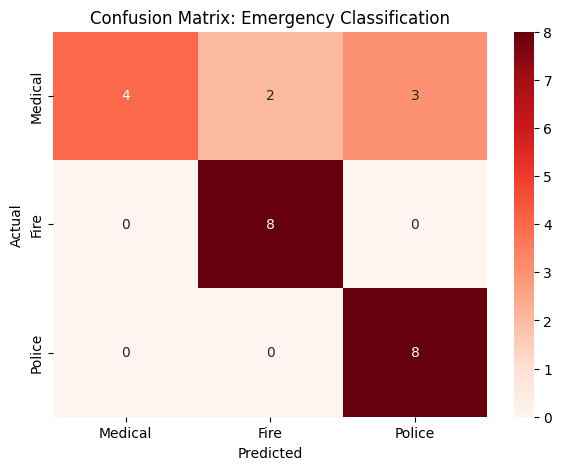

In [ ]:
cm = confusion_matrix(trues, preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=LABEL_MAP.values(), yticklabels=LABEL_MAP.values())
plt.title("Confusion Matrix: Emergency Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
def predict_emergency(text):
    if not text.strip(): return None
    enc = tokenizer(text, truncation=True, padding="max_length", max_length=64, return_tensors="pt").to(device)
    model.eval()
    with torch.no_grad():
        logits = model(**enc).logits
    probs = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
    label_id = np.argmax(probs)
    return {
        "label": LABEL_MAP[label_id],
        "conf": probs[label_id],
        "res": RESPONSES[label_id],
        "all": probs
    }

# --- GUI CODE ---
input_box = widgets.Text(placeholder='e.g., Shwasam muttunnnu or Fire in kitchen', description='Emergency:')
btn = widgets.Button(description='🚨 Dispatch Help', button_style='danger')
out = widgets.Output()

def on_click(b):
    with out:
        out.clear_output()
        res = predict_emergency(input_box.value)
        if not res: return

        # Color coding logic
        color = "#e74c3c" if res['label'] == "Fire" else "#3498db" if res['label'] == "Police" else "#2ecc71"

        display(HTML(f"""
        <div style="border: 3px solid {color}; padding: 20px; border-radius: 15px; background-color: #ffffff; font-family: sans-serif;">
            <h1 style="color: {color}; margin: 0; font-weight: bold;">{res['label'].upper()} DETECTED</h1>
            <p style="font-size: 18px; color: #333333;"><b>Confidence:</b> {res['conf']:.2%}</p>
            <div style="background: #f8f9fa; border-left: 10px solid {color}; padding: 15px; margin-top: 10px;">
                <h3 style="margin: 0; color: #333333;">Instruction:</h3>
                <p style="font-size: 16px; color: #222222; line-height: 1.5;">{res['res']}</p>
            </div>
            <p style="color: #777777; font-size: 12px; margin-top: 15px;">Analyzed Input: "{input_box.value}"</p>
        </div>
        """))

btn.on_click(on_click)
display(HTML("<h2>Smart Emergency Response System (mBERT)</h2>"), input_box, btn, out)

Text(value='', description='Emergency:', placeholder='e.g., Shwasam muttunnnu or Fire in kitchen')

Button(button_style='danger', description='🚨 Dispatch Help', style=ButtonStyle())

Output()